In [1]:
# ============================================================
# CLASSIFICATION VALIDITY ANALYSIS — Overath DATASET
# Research Question: To what extent do computational metrics
# reliably predict experimental binding affinity in PPI?
#
# Datasets:
#   - Overath et al. (2025)        binary labels   n≈3,676
#
# Strategy:
#   • Single combined analysis across all sources
#   • Per-metric analysis on ALL rows where that metric is
#     non-null (avoids listwise deletion; metrics vary by source)
#   • Source column "dataset" used only for availability audit
# ============================================================

import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.api as sm

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Metrics: col → (direction, display_label, type)
# "lower" = lower score means better binder → will be negated
METRIC_CFG = {
    "af3_ipSAE_min"            : ("higher",  "ipSAE_min (AF3, AI)",      "AI"),
    "af2_plddt_binder"         : ("higher", "Global pLDDT (AF2, AI)",    "AI"),
    "af2_pae_interaction"      : ("lower",  "PAE Interaction (AF2, AI)", "AI"),
    "af3_iptm_avg"             : ("higher", "ipTM (AF3, AI)",            "AI"),
    "af3_rosetta_interface_dG" : ("lower",  "Rosetta ΔG (AF3, Physics)", "Physics"),
}

# Colour scheme: AI metrics in blues, physics in orange
COLORS = {
    "af3_ipSAE_min"            : "#1f77b4",
    "af2_plddt_binder"         : "#aec7e8",
    "af2_pae_interaction"      : "#2196F3",
    "af3_iptm_avg"             : "#0d47a1",
    "af3_rosetta_interface_dG" : "#ff7f0e",
}

BOOTSTRAP_N  = 1000
RANDOM_STATE = 42


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("../../data/Overath/final_dataset.csv")

print("=" * 65)
print("OVERATH DATASET OVERVIEW")
print("=" * 65)
print(f"Total rows : {len(df)}")
print(f"Columns    : {df.columns.tolist()}\n")

print("Binding distribution (Overath):")
print(df["binder"].value_counts())
print(df["binder"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

# Keep only metrics that actually exist in the data
metric_cols = [m for m in METRIC_CFG if m in df.columns]
METRIC_CFG = {k: v for k, v in METRIC_CFG.items() if k in df.columns}
print(f"\nMetrics found in data: {list(METRIC_CFG.keys())}")

# Ensure binder is clean — drop rows where it is NaN or non-finite
before = len(df)
df = df[df["binder"].notna() & np.isfinite(df["binder"].astype(float))]
df["binder"] = df["binder"].astype(int)
print(f"Rows after cleaning binder: {len(df)}  (dropped {before - len(df)})")

# ============================================================
# METHOD COLUMN NORMALISATION
# Fixes cases like "bindcraft" vs "BindCraft" vs '"bindcraft"'
# (surrounding quotes, mixed case, leading/trailing whitespace)
# being counted as separate groups.
# ============================================================

METHOD_NORM_COLS = [c for c in ["structure_method", "assay_method", "design_method"]
                    if c in df.columns]

def normalise_method(series: pd.Series) -> pd.Series:
    """
    Normalise a method column so that formatting artefacts do not
    create spurious groups. Handles all of these patterns:

      Raw value           →  Normalised
      ─────────────────────────────────────────────────────────
      'bindcraft'         →  bindcraft
      "bindcraft"         →  bindcraft
      ["bindcraft"]       →  bindcraft        ← list with one item
      ['bindcraft']       →  bindcraft
      ["bindcraft","rf"]  →  bindcraft,rf     ← multi-item list
      BindCraft           →  bindcraft        ← case folding
      ' RFdiffusion '     →  rfdiffusion      ← whitespace
    """
    mask_null = series.isna()
    cleaned = series.astype(str).str.strip()

    # Strip list brackets  [ ... ]
    cleaned = cleaned.str.replace(r"^\[(.+)\]$", r"\1", regex=True)

    # Repeatedly strip surrounding quote characters until stable
    for _ in range(5):
        prev = cleaned.copy()
        cleaned = cleaned.str.strip("\"'`\u201c\u201d\u2018\u2019")
        cleaned = cleaned.str.strip()
        if cleaned.equals(prev):
            break

    # For multi-item lists like  "bindcraft", "rfdiffusion"
    # → strip quotes from each element, join with comma+space
    def clean_list_items(val):
        if "," in val:
            items = [item.strip().strip("\"'`\u201c\u201d\u2018\u2019").strip().lower()
                     for item in val.split(",")]
            return ", ".join(i for i in items if i)
        return val.lower()

    cleaned = cleaned.apply(clean_list_items)
    cleaned[mask_null] = np.nan
    return cleaned

print("\n── Method column normalisation ──")
for col in METHOD_NORM_COLS:
    # ── Diagnostic: show raw repr of every unique value before cleaning ──
    raw_unique = df[col].unique()
    print(f"\n  {col}  ({len(raw_unique)} unique values before normalisation):")
    for v in sorted(raw_unique, key=lambda x: str(x)):
        print(f"    repr: {repr(v)}")

    original = df[col].copy()
    df[col]  = normalise_method(df[col])

    # Build explicit before → after mapping
    mapping = {orig: norm for orig, norm in zip(original, df[col])
               if str(orig) != str(norm) and pd.notna(orig)}
    unique_mapping = {}
    for orig, norm in mapping.items():
        if str(orig) not in [str(k) for k in unique_mapping]:
            unique_mapping[orig] = norm

    after_unique = df[col].dropna().unique()
    print(f"  → {len(after_unique)} unique values after normalisation:")
    if unique_mapping:
        for orig, norm in unique_mapping.items():
            print(f"    Merged: {repr(orig)}  →  {repr(norm)}")
    else:
        print(f"    No changes needed.")
    print(f"  Final groups: {sorted(df[col].dropna().unique().tolist())}")

OVERATH DATASET OVERVIEW
Total rows : 3676
Columns    : ['binder_id', 'target_id', 'binder_chain', 'target_chains', 'target_chain_range', 'msa_info', 'binder', 'source', 'A_seq', 'A_length', 'B_seq', 'B_length', 'target_subchain_B_seq', 'target_subchain_B_len', 'target_subchain_C_seq', 'target_subchain_C_len', 'target_subchain_D_seq', 'target_subchain_D_len', 'af2_binder_aligned_rmsd', 'af2_pae_binder', 'af2_pae_interaction', 'af2_pae_target', 'af2_plddt_binder', 'af2_plddt_target', 'af2_plddt_total', 'af2_target_aligned_rmsd', 'af2_time', 'colab_actifptm_avg', 'colab_actifptm_std', 'colab_actifptm_model_0', 'colab_ptm_avg', 'colab_ptm_std', 'colab_ptm_model_0', 'colab_iptm_avg', 'colab_iptm_std', 'colab_iptm_model_0', 'boltz1_iptm_avg', 'boltz1_iptm_std', 'boltz1_iptm_model_0', 'boltz1_complex_plddt_avg', 'boltz1_complex_plddt_std', 'boltz1_complex_plddt_model_0', 'boltz1_complex_iplddt_avg', 'boltz1_complex_iplddt_std', 'boltz1_complex_iplddt_model_0', 'boltz1_complex_pde_avg', 'bolt

In [3]:
# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def oriented_scores(df_sub, metric_key):
    """Return scores where HIGHER = more likely binder."""
    direction = METRIC_CFG[metric_key][0]
    s = df_sub[metric_key].values.astype(float)
    return -s if direction == "lower" else s


def bootstrap_auc(y_true, scores, n=BOOTSTRAP_N, seed=RANDOM_STATE):
    """ROC-AUC and PR-AUC with 95% bootstrap CIs."""
    rng = np.random.RandomState(seed)
    roc_list, pr_list = [], []
    for _ in range(n):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        yt, ys = y_true[idx], scores[idx]
        if len(np.unique(yt)) < 2:
            continue
        roc_list.append(roc_auc_score(yt, ys))
        pr_list.append(average_precision_score(yt, ys))
    ra, pa = np.array(roc_list), np.array(pr_list)
    return (np.mean(ra), np.percentile(ra, 2.5), np.percentile(ra, 97.5),
            np.mean(pa), np.percentile(pa, 2.5), np.percentile(pa, 97.5))


def youden_threshold(fpr, tpr, thresholds):
    idx = np.argmax(tpr - fpr)
    return thresholds[idx], tpr[idx], fpr[idx]


def delong_test(y_true, sa, sb):
    """Approximate DeLong two-sided test. Returns z, p."""
    def sc(y, s):
        pos, neg = s[y == 1], s[y == 0]
        m, n = len(pos), len(neg)
        V10 = np.array([np.mean(p > neg) + .5 * np.mean(p == neg) for p in pos])
        V01 = np.array([np.mean(p < pos) + .5 * np.mean(p == pos) for p in neg])
        return np.mean(V10), np.var(V10, ddof=1) / m, np.var(V01, ddof=1) / n
    a1, s10a, s01a = sc(y_true, sa)
    a2, s10b, s01b = sc(y_true, sb)
    var = s10a + s01a + s10b + s01b
    z = (a1 - a2) / np.sqrt(var) if var > 0 else 0.
    return z, 2 * (1 - stats.norm.cdf(abs(z)))


def run_metric_analysis(df_sub, label="Overath"):
    """Run ROC/PR analysis for all available metrics on df_sub."""
    y = df_sub["binder"].astype(int)
    prevalence = y.mean()
    res = {}

    print(f"\n{'─'*65}")
    print(f"SUBSET: {label}  (n={len(df_sub)}, prevalence={prevalence*100:.1f}%)")
    print(f"{'─'*65}")

    for key in METRIC_CFG:
        sub = df_sub[["binder", key]].dropna()
        sub = sub[np.isfinite(sub[key])]   # drop inf in metric
        if len(sub) < 20 or sub["binder"].nunique() < 2:
            print(f"  {key:30s} — skipped (n={len(sub)}, insufficient data)")
            continue

        yt = sub["binder"].astype(int).values
        sc = oriented_scores(sub, key)

        fpr, tpr, thr = roc_curve(yt, sc)
        roc_auc = auc(fpr, tpr)
        pr_arr, rec_arr, _ = precision_recall_curve(yt, sc)
        pr_auc = average_precision_score(yt, sc)
        opt_t, opt_tpr, opt_fpr = youden_threshold(fpr, tpr, thr)
        roc_m, rlo, rhi, pr_m, plo, phi = bootstrap_auc(yt, sc)

        res[key] = dict(
            n=len(sub), yt=yt, sc=sc,
            fpr=fpr, tpr=tpr, thresholds=thr,
            roc_auc=roc_auc, roc_lo=rlo, roc_hi=rhi,
            pr_auc=pr_auc,   pr_lo=plo,  pr_hi=phi,
            opt_thresh=opt_t, opt_tpr=opt_tpr, opt_fpr=opt_fpr,
            precision=pr_arr, recall=rec_arr,
            prevalence=prevalence,
        )

        sig = "***" if rlo > 0.5 else ""  # CI entirely above chance
        print(
            f"  {key:30s}  n={len(sub):5d}  "
            f"ROC={roc_auc:.3f} [{rlo:.3f}–{rhi:.3f}]  "
            f"PR={pr_auc:.3f} [{plo:.3f}–{phi:.3f}]  {sig}"
        )

    return res

In [4]:
# ============================================================
# 3. COMBINED ANALYSIS — Overath
# ============================================================

# Single combined analysis — each metric evaluated on all its own available rows
results_full = run_metric_analysis(df, label="Overath (all sources combined)")


─────────────────────────────────────────────────────────────────
SUBSET: Overath (all sources combined)  (n=3669, prevalence=10.7%)
─────────────────────────────────────────────────────────────────
  af3_ipSAE_min                   n= 3669  ROC=0.787 [0.760–0.812]  PR=0.350 [0.301–0.402]  ***
  af2_plddt_binder                n= 3669  ROC=0.673 [0.647–0.699]  PR=0.158 [0.140–0.181]  ***
  af2_pae_interaction             n= 3669  ROC=0.721 [0.693–0.749]  PR=0.218 [0.191–0.254]  ***
  af3_iptm_avg                    n= 3669  ROC=0.751 [0.725–0.777]  PR=0.236 [0.208–0.267]  ***
  af3_rosetta_interface_dG        n= 3669  ROC=0.694 [0.666–0.720]  PR=0.187 [0.166–0.217]  ***


In [5]:
# ============================================================
# 4. DELONG PAIRWISE TESTS (Overath, common rows)
# ============================================================

print("\n" + "=" * 65)
print("DELONG PAIRWISE AUC TESTS (Overath, pairwise complete cases)")
print("=" * 65)

keys = list(results_full.keys())
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        ka, kb = keys[i], keys[j]
        # Intersect rows where both metrics available
        sub = df[["binder", ka, kb]].dropna()
        if len(sub) < 20 or sub["binder"].nunique() < 2:
            continue
        yt = sub["binder"].astype(int).values
        sa = oriented_scores(sub, ka)
        sb = oriented_scores(sub, kb)
        z, p = delong_test(yt, sa, sb)
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
        auc_a = roc_auc_score(yt, sa)
        auc_b = roc_auc_score(yt, sb)
        print(
            f"  {ka:25s} vs {kb:25s} | "
            f"ΔAUC={auc_a-auc_b:+.3f}  z={z:.2f}  p={p:.4f}  {sig}  n={len(sub)}"
        )


DELONG PAIRWISE AUC TESTS (Overath, pairwise complete cases)
  af3_ipSAE_min             vs af2_plddt_binder          | ΔAUC=+0.113  z=6.17  p=0.0000  ***  n=3669
  af3_ipSAE_min             vs af2_pae_interaction       | ΔAUC=+0.065  z=3.43  p=0.0006  ***  n=3669
  af3_ipSAE_min             vs af3_iptm_avg              | ΔAUC=+0.036  z=1.95  p=0.0516  n.s.  n=3669
  af3_ipSAE_min             vs af3_rosetta_interface_dG  | ΔAUC=+0.093  z=4.90  p=0.0000  ***  n=3669
  af2_plddt_binder          vs af2_pae_interaction       | ΔAUC=-0.048  z=-2.55  p=0.0107  *  n=3669
  af2_plddt_binder          vs af3_iptm_avg              | ΔAUC=-0.078  z=-4.23  p=0.0000  ***  n=3669
  af2_plddt_binder          vs af3_rosetta_interface_dG  | ΔAUC=-0.020  z=-1.09  p=0.2769  n.s.  n=3669
  af2_pae_interaction       vs af3_iptm_avg              | ΔAUC=-0.029  z=-1.55  p=0.1218  n.s.  n=3669
  af2_pae_interaction       vs af3_rosetta_interface_dG  | ΔAUC=+0.028  z=1.42  p=0.1550  n.s.  n=3669
  af3_iptm_avg

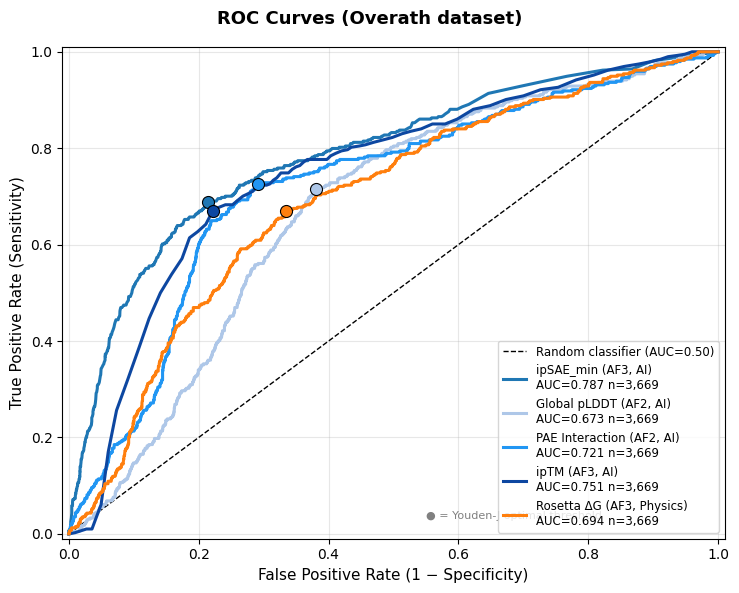

→ Saved: fig_roc_Overath.png


In [6]:
# ============================================================
# 5. FIGURE 1 — ROC CURVES  (single panel, Overath)
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 6))
fig.suptitle(
    "ROC Curves (Overath dataset)",
    fontsize=13, fontweight="bold"
)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier (AUC=0.50)")
for key, r in results_full.items():
    lbl = (f"{METRIC_CFG[key][1]}\n"
           f"AUC={r['roc_auc']:.3f} n={r['n']:,}")
    ax.plot(r["fpr"], r["tpr"], color=COLORS.get(key, "gray"), lw=2.2, label=lbl)
    ax.scatter(r["opt_fpr"], r["opt_tpr"],
               color=COLORS.get(key, "gray"), s=75, zorder=5,
               edgecolors="black", lw=0.8)

ax.set_xlabel("False Positive Rate (1 − Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
ax.legend(loc="lower right", fontsize=8.5)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)
ax.annotate("● = Youden-J optimal threshold", xy=(0.55, 0.03), fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("fig_roc_Overath.png", dpi=200, bbox_inches="tight")
plt.show()
print("→ Saved: fig_roc_Overath.png")

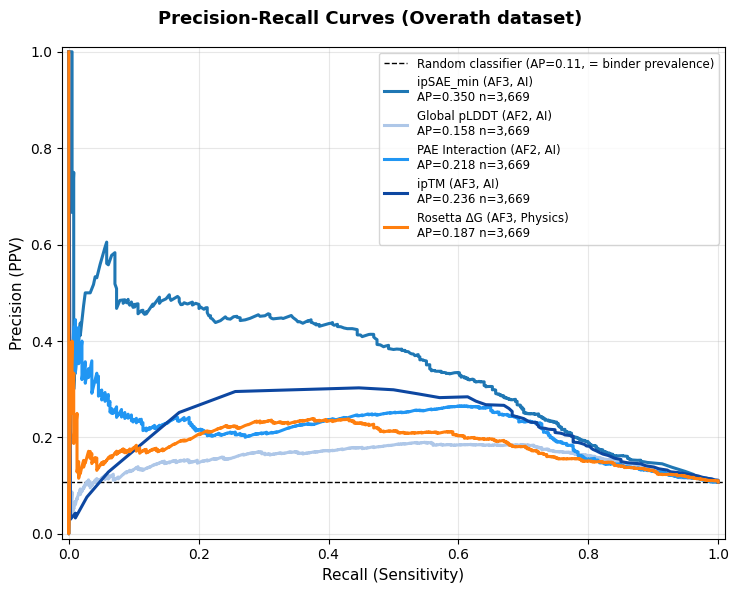

→ Saved: fig_pr_Overath.png


In [7]:
# ============================================================
# 6. FIGURE 2 — PR CURVES  (single panel, Overath)
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 6))
fig.suptitle(
    "Precision-Recall Curves (Overath dataset)",
    fontsize=13, fontweight="bold"
)

if results_full:
    base = list(results_full.values())[0]["prevalence"]
    ax.axhline(y=base, color="k", lw=1, ls="--",
               label=f"Random classifier (AP={base:.2f}, = binder prevalence)")

for key, r in results_full.items():
    lbl = (f"{METRIC_CFG[key][1]}\n"
           f"AP={r['pr_auc']:.3f} n={r['n']:,}")
    ax.plot(r["recall"], r["precision"], color=COLORS.get(key, "gray"), lw=2.2, label=lbl)

ax.set_xlabel("Recall (Sensitivity)", fontsize=11)
ax.set_ylabel("Precision (PPV)", fontsize=11)
ax.legend(loc="upper right", fontsize=8.5)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_pr_Overath.png", dpi=200, bbox_inches="tight")
plt.show()
print("→ Saved: fig_pr_Overath.png")

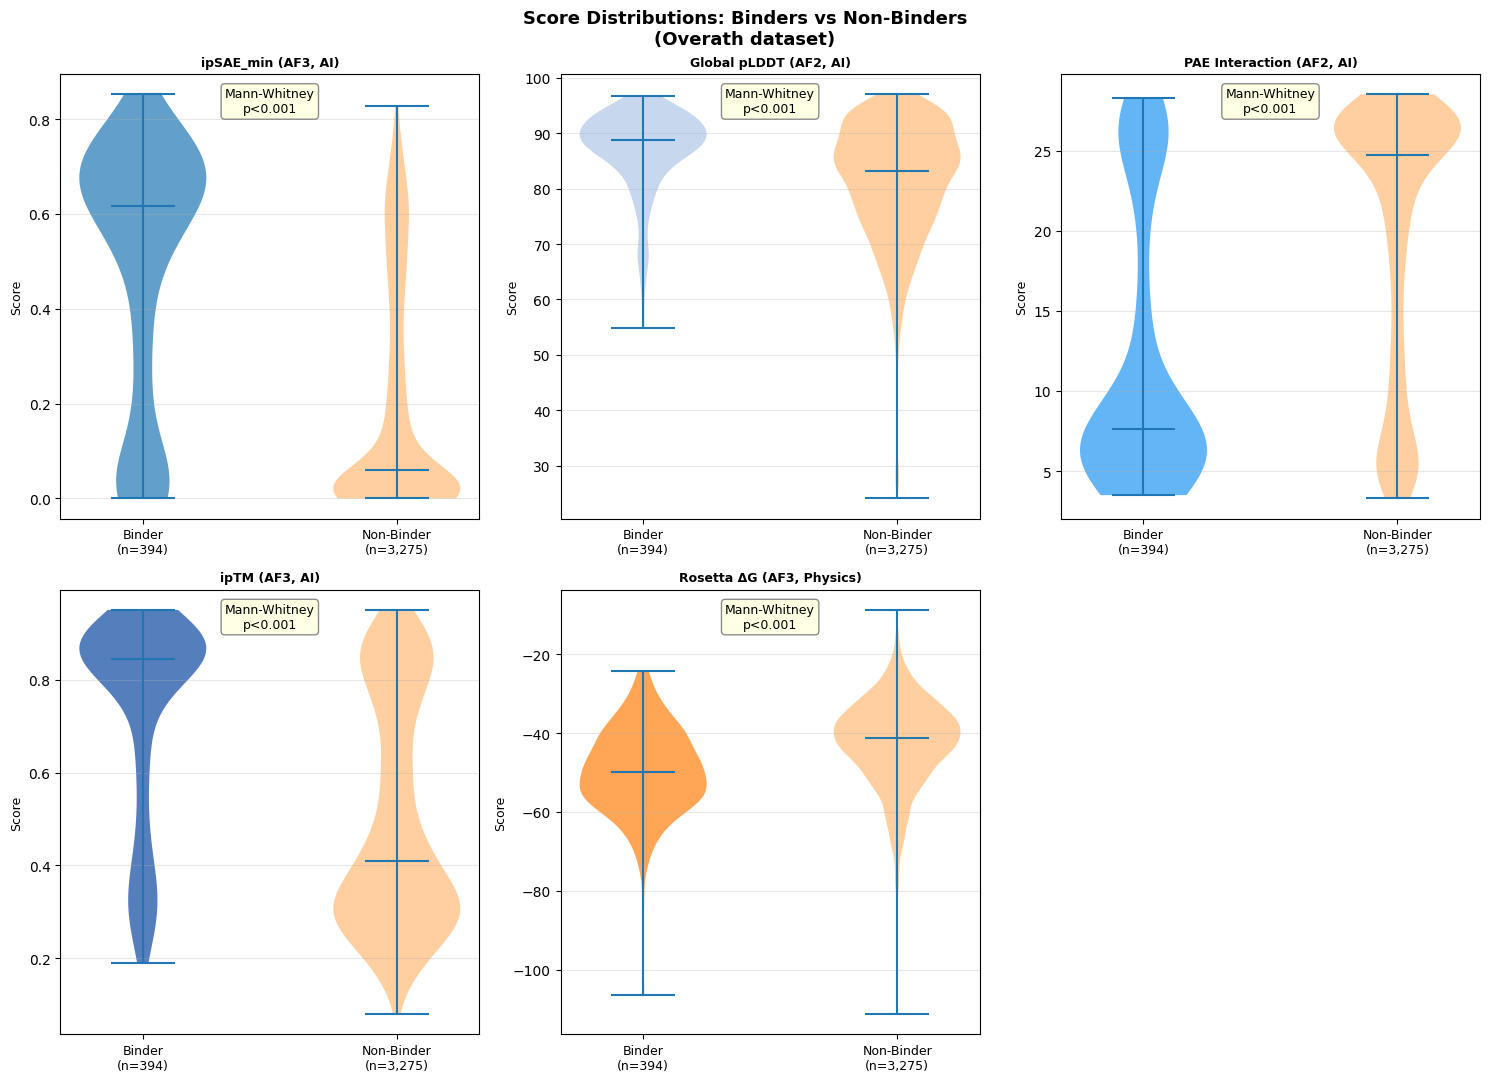

→ Saved: fig_distributions_Overath.png


In [8]:
# ============================================================
# 7. FIGURE 3 — Distribution analysis (violin, all metrics)
# Visualises score separation between binders / non-binders.
# Paper methods: "verified via distribution analysis (Figure X)"
# ============================================================

available_metrics = list(results_full.keys())
n = len(available_metrics)
numCol = math.ceil(n / 2)
numRow = 2 if n > 1 else 1

fig, axes = plt.subplots(numRow, numCol,
    figsize=(5 * numCol, 5.5 * numRow))

# Always work with a flat list of axes — fixes AttributeError on 2D array
axes_flat = np.array(axes).flatten()

# Hide any unused subplot slots (e.g. odd total metric count)
for i in range(n, len(axes_flat)):
    fig.delaxes(axes_flat[i])

fig.suptitle(
    "Score Distributions: Binders vs Non-Binders\n(Overath dataset)",
    fontsize=13, fontweight="bold"
)

for ax, key in zip(axes_flat, available_metrics):
    sub = df[["binder", key]].dropna()
    b  = sub.loc[sub["binder"] == 1, key]
    nb = sub.loc[sub["binder"] == 0, key]

    parts = ax.violinplot([b, nb], positions=[1, 2],
                          showmedians=True, showextrema=True)
    parts["bodies"][0].set_facecolor(COLORS.get(key, "#aec7e8"))
    parts["bodies"][0].set_alpha(0.7)
    parts["bodies"][1].set_facecolor("#ffbb78")
    parts["bodies"][1].set_alpha(0.7)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"Binder\n(n={len(b):,})", f"Non-Binder\n(n={len(nb):,})"],
                       fontsize=9)
    ax.set_title(METRIC_CFG[key][1], fontsize=9, fontweight="bold")
    ax.set_ylabel("Score", fontsize=9)

    stat_u, p_u = stats.mannwhitneyu(b, nb, alternative="two-sided")
    p_str = "p<0.001" if p_u < 0.001 else f"p={p_u:.3f}"
    ax.annotate(f"Mann-Whitney\n{p_str}", xy=(0.5, 0.97),
                xycoords="axes fraction", ha="center", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.9))
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_distributions_Overath.png", dpi=200)
plt.show()
print("→ Saved: fig_distributions_Overath.png")

In [9]:
# ============================================================
# 8. METHOD BIAS ANALYSIS
#    Three angles:
#    A) Cluster exploration — binding rate & score distribution
#       per structure_method / assay_method / design_method
#    B) AUC stratification — does metric performance vary by
#       method group? (test for confounding)
#    C) Control variables — add method dummies to logistic
#       regression; check whether metric ORs hold after adjustment
# ============================================================

METHOD_COLS = [c for c in ["structure_method", "assay_method", "design_method"]
               if c in df.columns]

print("\n" + "=" * 65)
print("METHOD BIAS ANALYSIS")
print("=" * 65)

if not METHOD_COLS:
    print("⚠ None of structure_method / assay_method / design_method found in data.")
else:
    print(f"Method columns found: {METHOD_COLS}\n")

    # ── 8A. Cluster exploration ─────────────────────────────
    print("── 8A. Binding rate & score distribution per method group ──")
    cluster_rows = []

    for mcol in METHOD_COLS:
        print(f"\n  {mcol}:")
        grp_counts = df[mcol].value_counts(dropna=False)
        # Collapse groups with < 20 rows into "Other"
        small = grp_counts[grp_counts < 20].index
        df[f"_{mcol}_grp"] = df[mcol].where(~df[mcol].isin(small), other="Other")

        for grp, gdf in df.groupby(f"_{mcol}_grp", dropna=False):
            n      = len(gdf)
            prev   = gdf["binder"].mean()
            row    = {"method_col": mcol, "group": str(grp), "n": n,
                      "binder_%": round(prev * 100, 1)}
            # pLDDT is the most widely available metric — always report it
            if "plddt" in gdf.columns:
                plddt_b  = gdf.loc[gdf["binder"] == 1, "plddt"].dropna()
                plddt_nb = gdf.loc[gdf["binder"] == 0, "plddt"].dropna()
                row["pLDDT_binder_median"]    = round(plddt_b.median(),  2) if len(plddt_b)  > 0 else np.nan
                row["pLDDT_nonbinder_median"] = round(plddt_nb.median(), 2) if len(plddt_nb) > 0 else np.nan
            cluster_rows.append(row)
            print(f"    {str(grp):35s}  n={n:5d}  binders={prev*100:.1f}%")

    cluster_df = pd.DataFrame(cluster_rows)
    cluster_df.to_csv("bias_cluster_summary.csv", index=False)
    print("\n→ Saved: bias_cluster_summary.csv")

    # ── 8A figure: binding prevalence heatmap per method group ─
    fig_cols = len(METHOD_COLS)
    fig, axes = plt.subplots(1, fig_cols, figsize=(6 * fig_cols, 7))
    if fig_cols == 1:
        axes = [axes]
    fig.suptitle("Binding Prevalence by Method Group\n",
                 fontsize=13, fontweight="bold")

    for ax, mcol in zip(axes, METHOD_COLS):
        sub = cluster_df[cluster_df["method_col"] == mcol].copy()
        sub = sub.sort_values("binder_%", ascending=True)
        colors_bar = ["#d73027" if v > 50 else "#4575b4" for v in sub["binder_%"]]
        bars = ax.barh(sub["group"].astype(str), sub["binder_%"], color=colors_bar, alpha=0.8)
        ax.axvline(x=df["binder"].mean() * 100, color="black",
                   lw=1.5, ls="--", label=f"Overall mean ({df['binder'].mean()*100:.1f}%)")
        ax.set_xlabel("Binder prevalence (%)", fontsize=10)
        ax.set_title(mcol, fontsize=11, fontweight="bold")
        for bar, (_, row) in zip(bars, sub.iterrows()):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"n={int(row['n'])}", va="center", fontsize=8)
        ax.legend(fontsize=8)
        ax.set_xlim([0, 105])
        ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig("fig_bias_prevalence.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("→ Saved: fig_bias_prevalence.png")

    # ── 8B. AUC stratified by method group ─────────────────
    # Uses pLDDT as the universal metric (present across all sources).
    # If ipSAE_min is available, also stratify by that.
    STRATIFY_METRICS = [k for k in ["plddt", "ipSAE_min"] if k in METRIC_CFG]

    print("\n── 8B. AUC stratified by method group (bias / confounding check) ──")
    strat_rows = []

    for mcol in METHOD_COLS:
        grp_col = f"_{mcol}_grp"
        for grp, gdf in df.groupby(grp_col, dropna=False):
            for key in STRATIFY_METRICS:
                sub = gdf[["binder", key]].dropna()
                sub = sub[np.isfinite(sub[key])]
                if len(sub) < 30 or sub["binder"].nunique() < 2:
                    continue
                yt = sub["binder"].astype(int).values
                sc = oriented_scores(sub, key)
                roc_a = roc_auc_score(yt, sc)
                _, rlo, rhi, _, _, _ = bootstrap_auc(yt, sc)
                strat_rows.append({
                    "method_col": mcol, "group": str(grp),
                    "metric": key, "n": len(sub),
                    "ROC_AUC": round(roc_a, 3),
                    "CI_lo": round(rlo, 3), "CI_hi": round(rhi, 3),
                })
                print(f"  {mcol:20s} | {str(grp):35s} | {key:20s} "
                      f"AUC={roc_a:.3f} [{rlo:.3f}–{rhi:.3f}]  n={len(sub)}")

    strat_df = pd.DataFrame(strat_rows)
    strat_df.to_csv("bias_auc_stratified.csv", index=False)
    print("→ Saved: bias_auc_stratified.csv")

    # ── 8B figure: AUC forest plot per group, one panel per method col ──
    for key in STRATIFY_METRICS:
        sub_strat = strat_df[strat_df["metric"] == key].copy()
        if sub_strat.empty:
            continue

        fig, axes = plt.subplots(1, len(METHOD_COLS),
                                 figsize=(6 * len(METHOD_COLS), max(4, len(sub_strat) * 0.4 + 2)))
        if len(METHOD_COLS) == 1:
            axes = [axes]
        fig.suptitle(f"AUC Forest Plot by Method Group — {METRIC_CFG[key][1]}\n"
                     f"(Checks whether metric performance is confounded by method type)",
                     fontsize=12, fontweight="bold")

        for ax, mcol in zip(axes, METHOD_COLS):
            sub_m = sub_strat[sub_strat["method_col"] == mcol].sort_values("ROC_AUC")
            if sub_m.empty:
                ax.set_visible(False)
                continue
            y_pos = range(len(sub_m))
            ax.scatter(sub_m["ROC_AUC"], y_pos, color=COLORS.get(key, "steelblue"),
                       s=60, zorder=5)
            for i, (_, row) in enumerate(sub_m.iterrows()):
                ax.plot([row["CI_lo"], row["CI_hi"]], [i, i],
                        color=COLORS.get(key, "steelblue"), lw=2, alpha=0.7)
            ax.axvline(x=results_full.get(key, {}).get("roc_auc", 0.5),
                       color="black", lw=1.5, ls="--",
                       label=f"Overall AUC={results_full.get(key, {}).get('roc_auc', 0):.3f}")
            ax.axvline(x=0.5, color="gray", lw=1, ls=":")
            ax.set_yticks(list(y_pos))
            ax.set_yticklabels(
                [f"{row['group']} (n={row['n']})" for _, row in sub_m.iterrows()],
                fontsize=8
            )
            ax.set_xlabel("ROC-AUC (95% CI)", fontsize=10)
            ax.set_title(mcol, fontsize=10, fontweight="bold")
            ax.set_xlim([0.3, 1.0])
            ax.legend(fontsize=8)
            ax.grid(True, axis="x", alpha=0.3)

        plt.tight_layout()
        fname = f"fig_bias_forest_{key}.png"
        plt.savefig(fname, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"→ Saved: {fname}")

    # ── 8C. Kruskal-Wallis test: do method groups differ on scores? ──
    print("\n── 8C. Kruskal-Wallis test: score differences across method groups ──")
    kw_rows = []
    for mcol in METHOD_COLS:
        grp_col = f"_{mcol}_grp"
        for key in STRATIFY_METRICS:
            groups = [
                grp[key].dropna().values
                for _, grp in df.groupby(grp_col)
                if grp[key].notna().sum() >= 5
            ]
            if len(groups) < 2:
                continue
            stat, p = stats.kruskal(*groups)
            sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
            kw_rows.append({"method_col": mcol, "metric": key,
                            "H": round(stat, 3), "p": round(p, 4), "sig": sig})
            print(f"  {mcol:20s} × {key:20s}  H={stat:.3f}  p={p:.4f}  {sig}")
            if p < 0.05:
                print(f"    ↳ Groups differ significantly on {key} — "
                      f"include {mcol} as control variable in regression.")

    pd.DataFrame(kw_rows).to_csv("bias_kruskal_wallis.csv", index=False)
    print("→ Saved: bias_kruskal_wallis.csv")


METHOD BIAS ANALYSIS
⚠ None of structure_method / assay_method / design_method found in data.


In [10]:
# ============================================================
# 9. LOGISTIC REGRESSION — UNADJUSTED + METHOD-CONTROLLED
# ============================================================

print("\n" + "=" * 65)
print("LOGISTIC REGRESSION — UNADJUSTED + METHOD-CONTROLLED")
print("=" * 65)

# Identify which method columns to include as controls.
# Only include a method column if its Kruskal-Wallis test for pLDDT
# was significant (p < 0.05), meaning it is a credible confounder.
# If bias analysis was skipped (columns absent), fall back to no controls.
CONTROL_COLS = []
if METHOD_COLS:
    for mcol in METHOD_COLS:
        grp_col = f"_{mcol}_grp"
        if grp_col not in df.columns:
            continue
        # Always include if present — let the researcher decide post-hoc
        CONTROL_COLS.append(grp_col)

def build_control_dummies(df_sub, control_cols):
    """
    One-hot encode method control columns (drop_first to avoid collinearity).
    Returns a DataFrame of dummies aligned to df_sub index.
    """
    parts = []
    for col in control_cols:
        if col not in df_sub.columns:
            continue
        dummies = pd.get_dummies(df_sub[col].astype(str), prefix=col,
                                 drop_first=True, dtype=float)
        parts.append(dummies)
    return pd.concat(parts, axis=1) if parts else pd.DataFrame(index=df_sub.index)


logit_summary = []

for key, (direction, label, mtype) in METRIC_CFG.items():
    base_cols = ["binder", key] + CONTROL_COLS
    available = [c for c in base_cols if c in df.columns]
    sub = df[available].dropna(subset=["binder", key])
    sub = sub[np.isfinite(sub[key])]
    if len(sub) < 30 or sub["binder"].nunique() < 2:
        continue

    yt = sub["binder"].astype(int)
    X_metric = sub[[key]].copy()
    if direction == "lower":
        X_metric[key] = -X_metric[key]
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_metric)

    # ── Model A: unadjusted ─────────────────────────────────
    X_A = sm.add_constant(X_sc)
    res_A = sm.Logit(yt, X_A).fit(disp=False, method="bfgs")
    coef_A = res_A.params[1]
    OR_A   = np.exp(coef_A)
    ci_A   = np.exp(res_A.conf_int().iloc[1])
    p_A    = res_A.pvalues[1]

    # ── Model B: method-controlled ──────────────────────────
    ctrl_dummies = build_control_dummies(sub, CONTROL_COLS)
    has_controls = not ctrl_dummies.empty

    if has_controls:
        X_ctrl = np.hstack([X_sc, ctrl_dummies.values])
        X_B    = sm.add_constant(X_ctrl)
        res_B  = sm.Logit(yt, X_B).fit(disp=False, method="bfgs")
        coef_B = res_B.params[1]
        OR_B   = np.exp(coef_B)
        ci_B   = np.exp(res_B.conf_int().iloc[1])
        p_B    = res_B.pvalues[1]
        # Likelihood-ratio test: does controlling for method improve fit?
        lr_stat = -2 * (res_A.llf - res_B.llf)
        lr_df   = res_B.df_model - res_A.df_model
        lr_p    = 1 - stats.chi2.cdf(lr_stat, df=max(lr_df, 1))
    else:
        OR_B = ci_B = p_B = lr_stat = lr_df = lr_p = None

    sig_A = "***" if p_A < 0.001 else ("**" if p_A < 0.01 else ("*" if p_A < 0.05 else "n.s."))

    row = {
        "Metric": label, "Type": mtype, "n": len(sub),
        "OR_unadj":       f"{OR_A:.3f}",
        "CI_unadj":       f"[{ci_A.iloc[0]:.3f}–{ci_A.iloc[1]:.3f}]",
        "p_unadj":        f"{p_A:.2e}",
        "Sig_unadj":      sig_A,
        "pseudo_R2_unadj": f"{res_A.prsquared:.4f}",
    }

    print(f"\n  {label}")
    print(f"    Unadjusted  OR={OR_A:.3f} [{ci_A.iloc[0]:.3f}–{ci_A.iloc[1]:.3f}]  "
          f"p={p_A:.2e} {sig_A}  pseudo-R²={res_A.prsquared:.4f}")

    if has_controls and OR_B is not None:
        sig_B = "***" if p_B < 0.001 else ("**" if p_B < 0.01 else ("*" if p_B < 0.05 else "n.s."))
        row.update({
            "OR_adj":       f"{OR_B:.3f}",
            "CI_adj":       f"[{ci_B.iloc[0]:.3f}–{ci_B.iloc[1]:.3f}]",
            "p_adj":        f"{p_B:.2e}",
            "Sig_adj":      sig_B,
            "pseudo_R2_adj": f"{res_B.prsquared:.4f}",
            "LR_chi2":      f"{lr_stat:.3f}",
            "LR_p":         f"{lr_p:.4f}",
        })
        delta_OR = OR_B - OR_A
        confound  = "⚠ possible confounding" if abs(delta_OR / OR_A) > 0.10 else "✓ robust to method control"
        print(f"    Adjusted    OR={OR_B:.3f} [{ci_B.iloc[0]:.3f}–{ci_B.iloc[1]:.3f}]  "
              f"p={p_B:.2e} {sig_B}  pseudo-R²={res_B.prsquared:.4f}")
        print(f"    ΔOR={delta_OR:+.3f}  LR χ²({lr_df:.0f})={lr_stat:.2f} p={lr_p:.4f}  {confound}")

    logit_summary.append(row)

logit_df = pd.DataFrame(logit_summary)
logit_df.to_csv("classification_logit_summary.csv", index=False)
print("\n→ Saved: classification_logit_summary.csv")


LOGISTIC REGRESSION — UNADJUSTED + METHOD-CONTROLLED

  ipSAE_min (AF3, AI)
    Unadjusted  OR=2.893 [2.585–3.238]  p=3.10e-76 ***  pseudo-R²=0.1634

  Global pLDDT (AF2, AI)
    Unadjusted  OR=2.204 [1.887–2.573]  p=1.58e-23 ***  pseudo-R²=0.0516

  PAE Interaction (AF2, AI)
    Unadjusted  OR=2.375 [2.129–2.649]  p=2.46e-54 ***  pseudo-R²=0.1081

  ipTM (AF3, AI)
    Unadjusted  OR=2.669 [2.356–3.024]  p=1.47e-53 ***  pseudo-R²=0.1175

  Rosetta ΔG (AF3, Physics)
    Unadjusted  OR=1.727 [1.568–1.903]  p=1.40e-28 ***  pseudo-R²=0.0492

→ Saved: classification_logit_summary.csv


In [11]:
# ============================================================
# 10. SUMMARY TABLE
# ============================================================

print("\n" + "=" * 65)
print("MASTER SUMMARY TABLE")
print("=" * 65)

rows = []
for key, r in results_full.items():
    rows.append({
        "Metric"     : METRIC_CFG[key][1],
        "Type"       : METRIC_CFG[key][2],
        "n"          : r["n"],
        "Prevalence" : f"{r['prevalence']*100:.1f}%",
        "ROC-AUC"    : f"{r['roc_auc']:.3f}",
        "ROC 95% CI" : f"[{r['roc_lo']:.3f}–{r['roc_hi']:.3f}]",
        "PR-AUC"     : f"{r['pr_auc']:.3f}",
        "PR 95% CI"  : f"[{r['pr_lo']:.3f}–{r['pr_hi']:.3f}]",
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv("classification_summary_Overath.csv", index=False)
print("\n→ Saved: classification_summary_Overath.csv")

print("\n" + "=" * 65)
print("ANALYSIS COMPLETE")
print("=" * 65)
print("""
INTERPRETATION NOTES:
──────────────────────────────────────────────────────────────
• Each metric is evaluated on ALL rows where it is non-null.
  This maximises statistical power and avoids artificially
  collapsing n to the smallest common subset (critical because
  ipSAE / Rosetta dG are only present in Overath, while pLDDT
  spans all sources).

• PR-AUC (Average Precision) is the primary metric because
  the Overath is class-imbalanced. A random classifier's AP
  equals the binder prevalence (shown as dashed baseline).

• DeLong tests formalise whether AI > Physics AUC differences
  are statistically significant — report these in your Results.

• Method bias analysis (Section 8) has three outputs:
  - bias_cluster_summary.csv + fig_bias_prevalence.png:
    binding prevalence per method group — reveals whether certain
    design/assay/structure methods are systematically over- or
    under-represented among binders (cluster exploration).
  - bias_auc_stratified.csv + fig_bias_forest_*.png:
    AUC per method group — if AUC varies strongly across groups,
    the metric's apparent performance may be confounded by method.
  - bias_kruskal_wallis.csv:
    Kruskal-Wallis test of score distributions across method groups;
    significant result (p<0.05) flags a method as a credible confounder.

• Logistic regression (Section 9) reports both an unadjusted OR and
  a method-controlled OR for each metric. A ΔOR > 10% between the
  two models indicates confounding; a stable OR confirms the metric
  effect is independent of how structures were generated / measured.

• Outputs: fig_roc_Overath.png, fig_pr_Overath.png,
  fig_distributions_Overath.png, fig_bias_prevalence.png,
  fig_bias_forest_*.png, classification_summary_Overath.csv,
  classification_logit_summary.csv, bias_cluster_summary.csv,
  bias_auc_stratified.csv, bias_kruskal_wallis.csv
──────────────────────────────────────────────────────────────
""")


MASTER SUMMARY TABLE
                   Metric    Type    n Prevalence ROC-AUC    ROC 95% CI PR-AUC     PR 95% CI
      ipSAE_min (AF3, AI)      AI 3669      10.7%   0.787 [0.760–0.812]  0.350 [0.301–0.402]
   Global pLDDT (AF2, AI)      AI 3669      10.7%   0.673 [0.647–0.699]  0.158 [0.140–0.181]
PAE Interaction (AF2, AI)      AI 3669      10.7%   0.721 [0.693–0.749]  0.218 [0.191–0.254]
           ipTM (AF3, AI)      AI 3669      10.7%   0.751 [0.725–0.777]  0.236 [0.208–0.267]
Rosetta ΔG (AF3, Physics) Physics 3669      10.7%   0.694 [0.666–0.720]  0.187 [0.166–0.217]

→ Saved: classification_summary_Overath.csv

ANALYSIS COMPLETE

INTERPRETATION NOTES:
──────────────────────────────────────────────────────────────
• Each metric is evaluated on ALL rows where it is non-null.
  This maximises statistical power and avoids artificially
  collapsing n to the smallest common subset (critical because
  ipSAE / Rosetta dG are only present in Overath, while pLDDT
  spans all sources).

• 